<a href="https://colab.research.google.com/github/ankitsingh435517/lichess-gpt/blob/main/lichess_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!sudo apt-get install zstd
!pip install chess

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 1s (1,065 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122815 files and direct

In [3]:
!wget -qO- https://database.lichess.org/standard/lichess_db_standard_rated_2026-08.pgn.zst | zstd -d | head -n 10000 > games.pgn

In [4]:
!wc -l games.pgn

10000 games.pgn


In [5]:
import chess.pgn

games = []
total_uci_moves = []
with open('games.pgn', 'r', encoding='utf-8') as f:
  while game := chess.pgn.read_game(f):
    uci_moves = []
    board = game.board()

    for move in game.mainline_moves():
      uci_moves.append(move.uci())
      board.push(move)
      total_uci_moves.append(move.uci())

    if uci_moves:
      games.append(uci_moves)

In [6]:
unique_uci_moves = set(total_uci_moves)
print(len(unique_uci_moves))

1733


In [7]:
len(games)

489

In [8]:
import matplotlib.pyplot as plt


Total Games:  24909
Total moves: 6705307
Average moves/game: 269.19213938737005
Total games: 24909
Unique games: 24832
Duplicates: 77
Duplicate rate: 0.0030912521578545515
 5 plies: 134 unique / 24,909 games
10 plies: 950 unique / 24,909 games
20 plies: 6,772 unique / 24,909 games
30 plies: 17,274 unique / 24,909 games
40 plies: 22,074 unique / 24,909 games
Min:  4
Max:  1064
Mean:  269.19213938737005
Median:  252.0
Std:  123.75801041205156


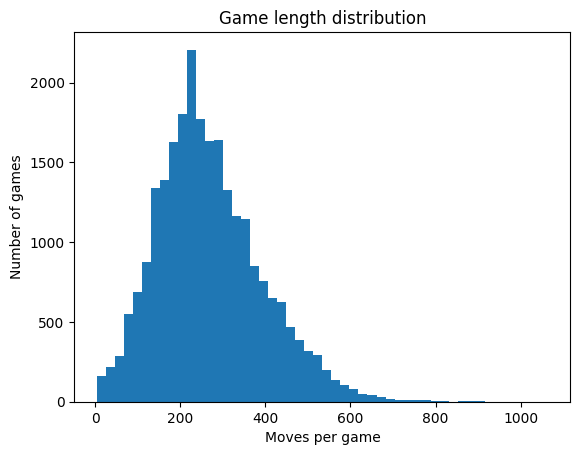

In [ ]:
# Measure dataset
import numpy as np

total_games = len(games)
total_moves = sum(len(game) for game in games)
lengths = np.array([len(game) for game in games])

print("Total Games: ", total_games)
print("Total moves:", total_moves)
print("Average moves/game:", total_moves / len(games))

game_strings = [
    " ".join(game)
    for game in games
]

unique_games = set(game_strings)

print("Total games:", len(game_strings))
print("Unique games:", len(unique_games))
print("Duplicates:", len(game_strings) - len(unique_games))

duplicate_rate = 1 - len(unique_games) / len(game_strings)

print("Duplicate rate:", duplicate_rate)

# check for variations in first N moves in each game
for n in [5, 10, 20, 30, 40]:
    prefixes = [tuple(game[:n]) for game in games]
    unique_prefixes = len(set(prefixes))

    print(
        f"{n:2d} plies: "
        f"{unique_prefixes:,} unique / {len(games):,} games"
    )

# distribution
print("Min: ", lengths.min())
print("Max: ", lengths.max())
print("Mean: ", lengths.mean())
print("Median: ", np.median(lengths))
print("Std: ", lengths.std())

plt.hist(lengths, bins=50)
plt.xlabel("Moves per game")
plt.ylabel("Number of games")
plt.title("Game length distribution")
plt.show()

In [ ]:
# build vocab
# text = "".join(games)
# chars = ['.'] + sorted(set(text))
# vocab_size = len(chars)
# stoi = {ch:i for i,ch in enumerate(chars)}
# itos = {i:ch for i,ch in enumerate(chars)}
# encode = lambda s: [stoi[ch] for ch in s]
# decode = lambda l: "".join(itos[i] for i in l)

# print(encode("e4"))
# print(decode(encode("e4")))

[13, 4]
e4


In [9]:
# full move uci tokenizer
vocab = ['.'] + sorted(unique_uci_moves)
vocab_size = len(sorted(vocab)) # all the unique moves are the vocabulary
move_to_id = {move:i for i, move in enumerate(vocab)}
id_to_move = {i:move for i, move in enumerate(vocab)}
encode = lambda moves: [move_to_id[move] for move in moves]
decode = lambda ids: ["".join(id_to_move[id] for id in ids)]

print(encode(["e2e4"]))
print(decode(encode(["e2e4"])))

[918]
['e2e4']


In [29]:
# tokenization - create a function which tokenizes into character level or BPE # train on both and check what is the different in training efficiency
# Character level tokenization

# compile dataset into train, eval and test split - 90, 5, 5 split
# the spit takes 90% of data to train due to the fact that the whole dataset is roughly 5000 games
# so 250 games to validate and test is sufficient enough and we need atleast 4000 games to train
import random
import torch

# shuffle the games to make the dataset represent overall structures of the games and avoid certain kinds of biased structures if there exists example similar openings in first few games etc
random.shuffle(games)

n1 = int(0.8*(len(games))) # 80%
n2 = int(0.9*len(games)) # 90%

context_size = 3

def compile_dataset(games):
  # compile the data into X and Y (X is the input sequence & Y is the corresponding output sequence)
  # we need context length of input for which output has to be stored e.g 3 for now so 3 moves input then we should expect 4th move as output
  X, Y = [], []
  for game in games:
    context = [0] * context_size # 0 0 0 -> meaning a '.' representing no move as in start of the game.
    for move in game + ["."]:
      ix = move_to_id[move]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  return X, Y

def split_dataset(split="train"):
  # split
  data = {
      'train': games[:n1],
      'dev': games[n1:n2],
      'test': games[n2:]
  }[split]
  # compile
  X, Y = compile_dataset(data)
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

Xtr, Ytr = split_dataset("train")
Xdev, Ydev = split_dataset("dev")
Xte, Yte = split_dataset("test")
print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)

torch.Size([27977, 3]) torch.Size([27977])
torch.Size([3600, 3]) torch.Size([3600])
torch.Size([3570, 3]) torch.Size([3570])


In [ ]:
# create Embedding for inputs (token & position embedding - what & where)
# We need a shape of (vocab_size, embd_dim) so that we can pluck out examples batch like B, T, C # Batch, Token, Channel e.g 32, 3, 10 meaning 32 examples where each example has 3 chars as integers and each have 10 dimension vector to represent their vector embedding
import torch.nn as nn
import torch.nn.functional as F

g = torch.Generator().manual_seed(1337)

embd_size = 10 # small reasonable embedding capacity for a small model
embd_table = nn.Embedding(vocab_size, embd_size)

batch_size = 256 # standard 32 size of batch
h_dim = 600 # how many neurons in hidden layer

ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
x = Xtr[ix] # (32, 3)
y = Ytr[ix] # (32,)

emb = embd_table(x) # expecting 32, 3, 16 # B, T, C
B, T, C = emb.shape
emb = emb.view(B, T * C) # (32, 3 * 16)

# this emb input can now be fed into nn
hidden_layer = nn.Linear(T * C, h_dim) # (B, T * C) @ (T * C, h_dim) => (B, h_dim)
logit_layer = nn.Linear(h_dim, vocab_size) # (B, h_dim) @ (h_dim, V) => (B, V)

# apply layers - MLP
hidden = torch.relu(hidden_layer(emb)) # (B, h_dim)
logits = logit_layer(hidden) # shape expected: (B, V)

# find the loss of this batch
loss = F.cross_entropy(logits, y) # aggregated scalalr loss likelihood over all batch examples
print(loss)

tensor(7.4768, grad_fn=<NllLossBackward0>)


In [ ]:
# optimization
# all the parameters
lr = 3e-4
wd = 0.01
params = (
    list(embd_table.parameters())
    + list(hidden_layer.parameters())
    + list(logit_layer.parameters())
)
total_params = sum(p.numel() for p in params)
print(total_params)
optimizer = torch.optim.Adam(params, lr=lr, weight_decay=wd)

1120074


In [ ]:
from math import inf

# Record the initial weights
before = logit_layer.weight.detach().clone()

train_lossi = []
dev_lossi = []
best_dev_loss = float("inf")

for step in range(10000):
    # batch sample
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    x = Xtr[ix] # (32, 3)
    y = Ytr[ix] # (32,)

    # forward pass
    emb = embd_table(x).reshape(x.shape[0], -1)
    hidden = torch.relu(hidden_layer(emb))
    logits = logit_layer(hidden)
    loss = F.cross_entropy(logits, y)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # print loss
    if step % 1000 == 0:
        print(loss.item())

    if step % 500 == 0:
      # compare the loss on entire train and val split
      @torch.no_grad()
      def evaluate(X, Y, split="Train"):
        emb = embd_table(X)
        emb = emb.reshape(emb.shape[0], -1)
        hidden = torch.relu(hidden_layer(emb))
        logits = logit_layer(hidden)
        return F.cross_entropy(logits, Y).item()

      train_loss = evaluate(Xtr, Ytr, "Train")
      train_lossi.append({
            "step": step,
            "loss": train_loss
      })
      eval_loss = evaluate(Xdev, Ydev, "dev")
      dev_lossi.append({
            "step": step,
            "loss": eval_loss
        })
      if eval_loss < best_dev_loss:
        # save the best loss as checkpoint
        torch.save({
            "step": step,
            "eval_loss": eval_loss,
            "embd_table": embd_table.state_dict(),
            "hidden_layer": hidden_layer.state_dict(),
            "logit_layer": logit_layer.state_dict()
        }, 'best_checkpoint.pt')
        print(f"Saved best checkpoint at step {step}, loss {eval_loss:.4f} ")
        best_dev_loss = eval_loss

after = logit_layer.weight.detach()
print("Weight change:", (after - before).norm().item())

6.2140374183654785
Saved best checkpoint at step 0, loss 6.0677 
6.271713733673096
5.988040447235107
6.096513748168945
6.157220840454102
6.160740852355957
6.09096622467041
6.246630668640137
6.223828315734863
6.161472320556641
Weight change: 3.1579978466033936


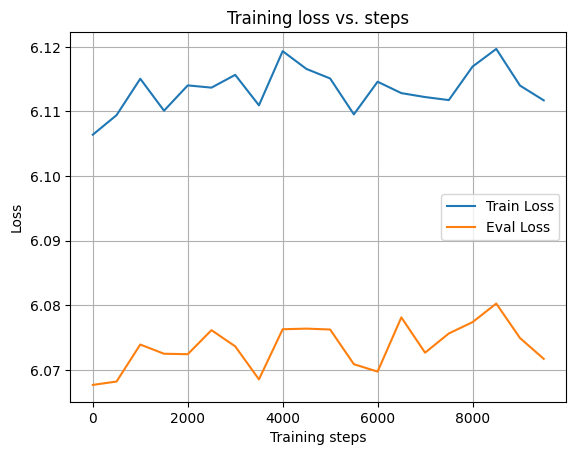

In [ ]:
# plot the losses
plt.plot([x["step"] for x in train_lossi], [x["loss"] for x in train_lossi], label="Train Loss")
plt.plot([x["step"] for x in dev_lossi], [x["loss"] for x in dev_lossi], label="Eval Loss")

plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.title("Training loss vs. steps")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best = min(dev_lossi, key=lambda x: x["loss"])

print("Best eval step:", best["step"])
print("Best eval loss:", best["loss"])

Best eval step: 0
Best eval loss: 6.067671298980713


In [ ]:
# load the model on best checkpoint
checkpoint = torch.load("best_checkpoint.pt", weights_only=True)

embd_table.load_state_dict(checkpoint["embd_table"])
hidden_layer.load_state_dict(checkpoint["hidden_layer"])
logit_layer.load_state_dict(checkpoint["logit_layer"])

print("Best step: ", checkpoint["step"])
print("Best eval loss: ", checkpoint["eval_loss"])

Best step:  0
Best eval loss:  6.067671298980713


In [ ]:
# eval - run loss on dev split
# batch sample
ix = torch.randint(0, Xdev.shape[0], (batch_size,), generator=g)
xd = Xdev[ix] # (32, 3)
yd = Ydev[ix] # (32,)

# forward pass
emb = embd_table(xd)
emb = emb.reshape(emb.shape[0], -1)
logits = logit_layer(torch.relu(hidden_layer(emb)))
loss = F.cross_entropy(logits, yd)
print(loss.item())

6.1306657791137695


In [ ]:
# Evaluate on the entire validation set
with torch.no_grad():
    emb = embd_table(Xdev)
    emb = emb.reshape(emb.shape[0], -1)

    hidden = torch.relu(hidden_layer(emb))
    logits = logit_layer(hidden)

    loss = F.cross_entropy(logits, Ydev)

print("Validation loss:", loss.item())

Validation loss: 6.067671298980713


In [ ]:
# compare the loss on entire train and val split
@torch.no_grad()
def evaluate(X, Y):
    emb = embd_table(X)
    emb = emb.reshape(emb.shape[0], -1)
    hidden = torch.relu(hidden_layer(emb))
    logits = logit_layer(hidden)
    return F.cross_entropy(logits, Y).item()

print("Train loss:", evaluate(Xtr, Ytr))
print("Validation loss:", evaluate(Xdev, Ydev))

Train loss: 6.106403827667236
Validation loss: 6.067671298980713


In [ ]:
# inference - run generation on test split
@torch.no_grad()
def model(X):
  emb = embd_table(X)
  emb = emb.reshape(emb.shape[0], -1)
  hidden = torch.relu(hidden_layer(emb))
  logits = logit_layer(hidden)
  return logits

def generate(max_new_tokens=50):
  context = [0] * context_size
  out = []
  for _ in range(max_new_tokens):
    X = torch.tensor([context])
    logits = model(X)
    probs = F.softmax(logits, dim=-1)
    next_id = torch.multinomial(probs, num_samples=1)
    tok_id = next_id.item()
    out.append(tok_id)
    context = context[1:] + [tok_id]

    if tok_id == 0:
      break

  return out

print(decode(generate()))

['a5d8d4a1f3h3d6c5d7f5e4g4a8d5e6d7d7b8g2g1qe4d2d6e6c4d4h4h6d2b2a5b7d5c7c7d8h4g6h2c7d7h3h8b8f8g8h6h1a1a2g5g4b6b7c1f4g8g1g1f1h5f3a4d7f4g6d4d1d2g2e2h2f6g6d3c1a4c2d8e7e4e5f1h2a3g3c6c5b2a1f3d3c3d4h3e6a5f5b7c6']


In [ ]:
# --------
# Train the transformer on full uci move tokenization on larger dataset of 1k games
# Compare losses on UCI + MLP vs UCI + transformer
# -------
# Start the experiment on mech interp.
# -------
# Move the code to vscode
# Write up

In [30]:
import torch.nn as nn
import torch.nn.functional as F

g = torch.Generator().manual_seed(1337)

class MLP(nn.Module):
  def __init__(self, n_embd, h_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(n_embd, h_dim)
    self.relu = nn.ReLU()
    self.output_layer = nn.Linear(h_dim, n_embd)

  def forward(self, x):
    x = self.relu(self.hidden_layer(x))
    out = self.output_layer(x)
    return out

In [31]:
import math

class Head(nn.Module):
  def __init__(self, n_embd, head_size, context_size):
    super().__init__()
    self.head_size = head_size
    self.Q = nn.Linear(n_embd, head_size)
    self.K = nn.Linear(n_embd, head_size)
    self.V = nn.Linear(n_embd, head_size)
    self.register_buffer(
        "tril",
        torch.tril(torch.ones(context_size, context_size)) # to match (B, T, T) each example will have T * T attention matrix where each row is a query and each column of that row is the key it needs to attend
    )

  def forward(self, x):
    q = self.Q(x)
    k = self.K(x)
    v = self.V(x)

    s = q @ k.transpose(-2, -1)
    s = s / math.sqrt(self.head_size)

    # causal mask
    mask = self.tril[:x.size(1), :x.size(1)]
    s = s.masked_fill(mask == 0, float("-inf"))

    w = F.softmax(s, dim=-1)

    o = w @ v

    return o

In [32]:
class MHA(nn.Module):
  def __init__(self, n_embd, head_size, n_head, context_size):
    super().__init__()
    self.heads = nn.ModuleList([
        Head(n_embd, head_size, context_size) for _ in range(n_head)
    ])
    self.out_layer = nn.Linear(n_embd, n_embd)

  def forward(self, x):
    outputs = [head(x) for head in self.heads]
    out = torch.cat(outputs, dim=-1)
    out = self.out_layer(out)
    return out

In [33]:
class Block(nn.Module):
  def __init__(self, n_embd, n_head, h_dim, context_size):
    super().__init__()
    head_size = n_embd // n_head
    self.mha = MHA(n_embd, head_size, n_head, context_size)
    self.mlp = MLP(n_embd, h_dim)
    self.ln1 = nn.LayerNorm(n_embd)
    self.ln2 = nn.LayerNorm(n_embd)

  def forward(self, x):
    x1 = x + self.mha(self.ln1(x))
    x2 = x1 + self.mlp(self.ln2(x1))
    return x2

In [38]:
n_blocks = 4
n_embd = 10
n_head = 5
h_dim = 4 * n_embd
context_size = 3
class GPT(nn.Module):
  def __init__(self):
    super().__init__()
    self.blocks = nn.ModuleList([
        Block(n_embd, n_head, h_dim, context_size) for _ in range(n_blocks)
    ])
    self.embd_table = nn.Embedding(vocab_size, n_embd)
    self.pos_embd_table = nn.Embedding(context_size, n_embd)
    self.final_ln = nn.LayerNorm(n_embd)
    self.linear = nn.Linear(n_embd, vocab_size)

  def forward(self, x, y=None):
    tok_emb = self.embd_table(x)

    T = tok_emb.shape[1]
    pos_ids = torch.arange(T)
    pos_emb = self.pos_embd_table(pos_ids)

    x = tok_emb + pos_emb

    for block in self.blocks:
      x = block(x)

    x = self.final_ln(x)
    logits = self.linear(x)
    logits = logits[:, -1, :]
    if y is None:
      return logits
    loss = F.cross_entropy(logits, y)
    return logits, loss

In [39]:
# model
model = GPT()

In [40]:
# optimizer
lr = 3e-4
wd = 0.01

total_params = sum(p.numel() for p in model.parameters())
print(total_params)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

41784


In [41]:
# train
batch_size = 32
train_lossi = []
dev_lossi = []
best_dev_loss = float("inf")

for step in range(10000):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  x = Xtr[ix]
  y = Ytr[ix]

  # forward pass
  logits, loss = model(x, y)

  # backward pass
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # print loss
  if step % 1000 == 0:
    print(loss.item())

  if step % 500 == 0:
    # compare the loss on entire train and val split
    @torch.no_grad()
    def evaluate(X, Y, split="Train"):
      logits, loss = model(X, Y)
      return loss.item()

    train_loss = evaluate(Xtr, Ytr, "Train")
    train_lossi.append({
          "step": step,
          "loss": train_loss
    })
    eval_loss = evaluate(Xdev, Ydev, "dev")
    dev_lossi.append({
          "step": step,
          "loss": eval_loss
      })
    if eval_loss < best_dev_loss:
      # save the best loss as checkpoint
      torch.save({
          "step": step,
          "eval_loss": eval_loss,
          "model_state_dict": model.state_dict()
      }, 'best_checkpoint.pt')
      print(f"Saved best checkpoint at step {step}, loss {eval_loss:.4f} ")
      best_dev_loss = eval_loss

7.828019142150879
Saved best checkpoint at step 0, loss 7.6904 
Saved best checkpoint at step 500, loss 7.3123 
7.0440216064453125
Saved best checkpoint at step 1000, loss 7.0709 
Saved best checkpoint at step 1500, loss 6.8834 
6.8119072914123535
Saved best checkpoint at step 2000, loss 6.7802 
Saved best checkpoint at step 2500, loss 6.7271 
6.724006175994873
Saved best checkpoint at step 3000, loss 6.7019 
Saved best checkpoint at step 3500, loss 6.6872 
6.558718204498291
Saved best checkpoint at step 4000, loss 6.6767 
Saved best checkpoint at step 4500, loss 6.6688 
6.555789470672607
Saved best checkpoint at step 5000, loss 6.6637 
Saved best checkpoint at step 5500, loss 6.6601 
6.628515243530273
Saved best checkpoint at step 6000, loss 6.6578 
Saved best checkpoint at step 6500, loss 6.6573 
6.323098659515381
Saved best checkpoint at step 7500, loss 6.6528 
6.928506851196289
Saved best checkpoint at step 8500, loss 6.6519 
6.382355690002441
Saved best checkpoint at step 9000, lo

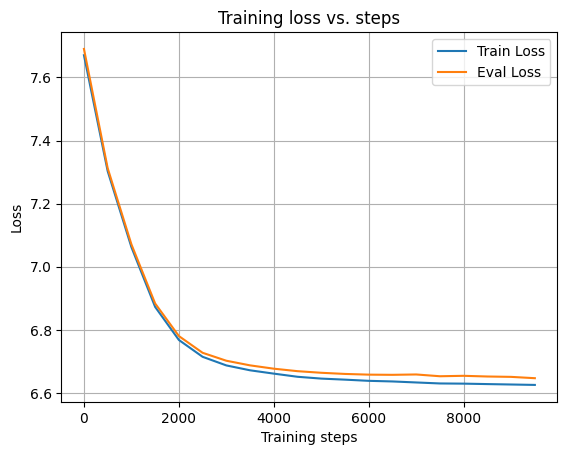

In [42]:
# plot the losses
plt.plot([x["step"] for x in train_lossi], [x["loss"] for x in train_lossi], label="Train Loss")
plt.plot([x["step"] for x in dev_lossi], [x["loss"] for x in dev_lossi], label="Eval Loss")

plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.title("Training loss vs. steps")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
# load the last best checkpoint
checkpoint = torch.load("best_checkpoint.pt")

model.load_state_dict(checkpoint["model_state_dict"])

step = checkpoint["step"]
eval_loss = checkpoint["eval_loss"]

In [46]:
@torch.no_grad()
def evaluate(X, Y, split="Train"):
  logits, loss = model(X, Y)
  return loss.item()

print("Train loss:", evaluate(Xtr, Ytr))
print("Validation loss:", evaluate(Xdev, Ydev))

Train loss: 6.625253677368164
Validation loss: 6.646569728851318


In [47]:
def generate(max_new_tokens=50):
  context = [0] * context_size
  out = []
  for _ in range(max_new_tokens):
    X = torch.tensor([context])
    logits = model(X)
    probs = F.softmax(logits, dim=-1)
    next_id = torch.multinomial(probs, num_samples=1)
    tok_id = next_id.item()
    out.append(tok_id)
    context = context[1:] + [tok_id]

    if tok_id == 0:
      break

  return out

print(decode(generate()))

['f8e8e2e4h7h5g5f7f8f7a6f6b5a4d8e7d7d4c2c4d8d6d6h2d7d5f8b4d4e5c1f4g3e2f5g4h7h5h5d5a8c8d4d7b6c7d7d6d4b3d5e6g5f6f7g8e2e4d6b5d3f5d6f4b2b4a1e1c3c1e8g8c1g5f8e7c1e3d7d6b1c3d6c6c5c4d4e5c2c1d4e5g2h2g8c4b8c6a7b6']
